# 24RB1003 松澤颯斗

# 演習2：グリッドワールドの価値反復

### 課題：3×3 グリッドワールドに対して価値反復を実装する

3×3 グリッドを考える．状態は格子点，行動は上下左右への移動である．  
ゴールは $G=(3,3)$，割引率は $\gamma=0.9$ とする．

- 移動先が盤内ならそのマスへ進む．  
- 移動先が盤外なら，同じ場所に留まる．  
- ゴール $G$ に入るときだけ報酬 $1$ を得る．  
- ゴール $G$ は終端状態なので，毎回 $V(G)=0$ に固定する．  

行うことは以下である．

1. 価値反復

$$
V_{k+1}(s)=\max_a \left[ r(s,a,f(s,a))+\gamma V_k(f(s,a)) \right]
$$

を実装する．  
2. $V_1,V_2,V_3,\ldots$ を順に表示し，価値がゴールから逆向きに伝播する様子を観察する．  
3. 収束した $V^*$ と貪欲方策を可視化する．  
4. 各状態でゴールまでの最短距離 $d$ を使った理論値 $V^*(s)=\gamma^{d-1}$ と一致するか確認する．

In [1]:
import os
os.environ["MPLCONFIGDIR"] = "/tmp/matplotlib"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

import warnings
warnings.filterwarnings("ignore")

### グリッドワールドを定義する

In [2]:
# グリッドサイズ，ゴール，割引率を設定する
grid_size = 3
goal = (3, 3)
gamma = 0.9

# 状態集合 S = {(i, j): i, j in {1, 2, 3}}
states = [(i, j) for i in range(1, grid_size + 1)
                 for j in range(1, grid_size + 1)]

# 行動集合 A = {↑, ↓, ←, →}
actions = {
    "↑": (-1, 0),
    "↓": (1, 0),
    "←": (0, -1),
    "→": (0, 1),
}

print("states:", states)
print("actions:", actions)
print("goal:", goal)
print("gamma:", gamma)

states: [(1, 1), (1, 2), (1, 3), (2, 1), (2, 2), (2, 3), (3, 1), (3, 2), (3, 3)]
actions: {'↑': (-1, 0), '↓': (1, 0), '←': (0, -1), '→': (0, 1)}
goal: (3, 3)
gamma: 0.9


### 遷移関数と報酬関数を作る

In [3]:
def in_grid(state):
    """状態が盤内にあるかを判定する関数"""
    i, j = state
    return 1 <= i <= grid_size and 1 <= j <= grid_size


def next_state(state, action):
    """状態 state で action を取ったときの次状態を返す関数"""
    # ゴールは吸収状態として扱う
    if state == goal:
        return goal

    di, dj = actions[action]
    candidate = (state[0] + di, state[1] + dj)

    # 盤内なら移動し，盤外なら同じ場所に留まる
    if in_grid(candidate):
        return candidate
    else:
        return state


def reward(state, action, next_s):
    """状態 state で action を取り，next_s に移ったときの即時報酬を返す関数"""
    # ゴールに入るときだけ報酬 1 を得る
    if state != goal and next_s == goal:
        return 1.0
    else:
        return 0.0


# いくつかの遷移と報酬を確認する
examples = [((1, 1), "↑"), ((1, 1), "→"), ((2, 3), "↓"), ((3, 3), "←")]

for s, a in examples:
    s_next = next_state(s, a)
    r = reward(s, a, s_next)
    print(f"s={s}, a={a} -> s'={s_next}, reward={r}")

s=(1, 1), a=↑ -> s'=(1, 1), reward=0.0
s=(1, 1), a=→ -> s'=(1, 2), reward=0.0
s=(2, 3), a=↓ -> s'=(3, 3), reward=1.0
s=(3, 3), a=← -> s'=(3, 3), reward=0.0


### 1. 価値反復を実装する

今回は決定的な環境なので，更新式は次のようになる．

$$
V_{k+1}(s)=\max_a \left[ r(s,a,f(s,a))+\gamma V_k(f(s,a)) \right]
$$

ただし，終端状態 $G$ は更新せず，常に $V(G)=0$ とする．

In [4]:
def state_to_index(state):
    """状態 (i, j) を配列の添字に変換する関数"""
    i, j = state
    return i - 1, j - 1


def get_value(V, state):
    """価値関数 V から状態 state の価値を取り出す関数"""
    i, j = state_to_index(state)
    return V[i, j]


def value_iteration(theta=1e-10, max_iter=100):
    """グリッドワールドで価値反復を行う関数"""
    V = np.zeros((grid_size, grid_size))
    history = [V.copy()]
    deltas = []

    for iteration in range(max_iter):
        V_new = V.copy()
        delta = 0.0

        for s in states:
            # 終端状態は毎回 0 に固定する
            if s == goal:
                i, j = state_to_index(s)
                V_new[i, j] = 0.0
                continue

            # 各行動の 1 ステップ先読み価値を計算する
            q_values = []
            for a in actions:
                s_next = next_state(s, a)
                r = reward(s, a, s_next)
                q = r + gamma * get_value(V, s_next)
                q_values.append(q)

            new_value = max(q_values)

            i, j = state_to_index(s)
            V_new[i, j] = new_value
            delta = max(delta, abs(new_value - V[i, j]))

        V = V_new
        history.append(V.copy())
        deltas.append(delta)

        if delta < theta:
            break

    return V, history, deltas


V_star, history, deltas = value_iteration(theta=1e-10, max_iter=100)

print("反復回数:", len(deltas))
print("最後の更新幅:", deltas[-1])
print("V_star shape:", V_star.shape)

反復回数: 5
最後の更新幅: 0.0
V_star shape: (3, 3)


### 2. $V_1,V_2,V_3,\ldots$ を順に表示する

In [5]:
def value_to_dataframe(V):
    """価値関数を見やすい DataFrame に変換する関数"""
    df = pd.DataFrame(
        V,
        index=[f"i={i}" for i in range(1, grid_size + 1)],
        columns=[f"j={j}" for j in range(1, grid_size + 1)],
    )
    return df.round(3)


# V0 から収束までを順に表示する
for k, V in enumerate(history):
    print(f"V_{k}")
    display(value_to_dataframe(V))

V_0


,j=1,j=2,j=3
i=1,0.0,0.0,0.0
i=2,0.0,0.0,0.0
i=3,0.0,0.0,0.0


V_1


,j=1,j=2,j=3
i=1,0.0,0.0,0.0
i=2,0.0,0.0,1.0
i=3,0.0,1.0,0.0


V_2


...

,j=1,j=2,j=3
i=1,0.00,0.81,0.9
i=2,0.81,0.90,1.0
i=3,0.90,1.00,0.0


V_4


,j=1,j=2,j=3
i=1,0.729,0.81,0.9
i=2,0.810,0.90,1.0
i=3,0.900,1.00,0.0


V_5


,j=1,j=2,j=3
i=1,0.729,0.81,0.9
i=2,0.810,0.90,1.0
i=3,0.900,1.00,0.0


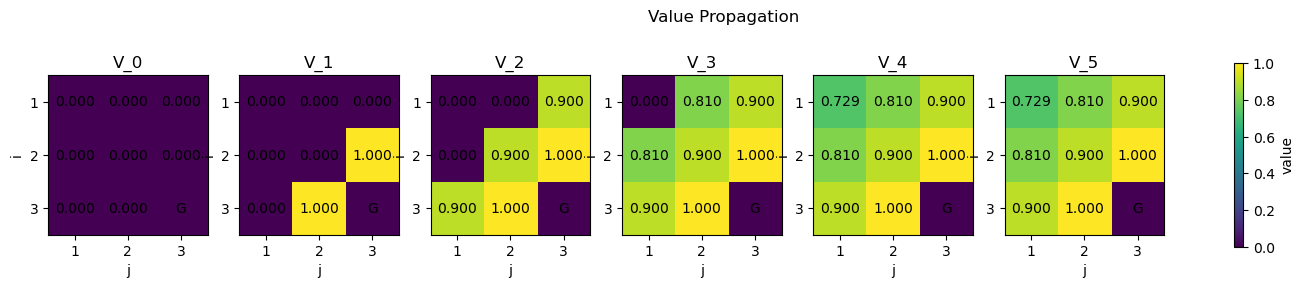

In [6]:
# 価値がゴールから逆向きに伝播する様子をヒートマップで確認する
num_plots = len(history)
fig, axes = plt.subplots(1, num_plots, figsize=(3.0 * num_plots, 3))

if num_plots == 1:
    axes = [axes]

vmax = max(V.max() for V in history)

for k, ax in enumerate(axes):
    V = history[k]
    im = ax.imshow(V, vmin=0, vmax=vmax)

    ax.set_title(f"V_{k}")
    ax.set_xticks(range(grid_size))
    ax.set_yticks(range(grid_size))
    ax.set_xticklabels(range(1, grid_size + 1))
    ax.set_yticklabels(range(1, grid_size + 1))
    ax.set_xlabel("j")
    ax.set_ylabel("i")

    for i in range(grid_size):
        for j in range(grid_size):
            state = (i + 1, j + 1)
            if state == goal:
                text = "G"
            else:
                text = f"{V[i, j]:.3f}"
            ax.text(j, i, text, ha="center", va="center")

fig.colorbar(im, ax=axes, shrink=0.8, label="value")
plt.suptitle("Value Propagation")
plt.show()

### 3. 収束した $V^*$ と貪欲方策を可視化する

In [7]:
def q_value(V, state, action):
    """価値関数 V に対する 1 ステップ先読み価値を計算する関数"""
    s_next = next_state(state, action)
    r = reward(state, action, s_next)
    return r + gamma * get_value(V, s_next)


def greedy_policy(V, tol=1e-12):
    """価値関数 V に対する貪欲方策を求める関数

    同じ最大値を取る行動が複数ある場合は，複数の矢印を表示する．
    """
    policy = {}
    q_table = {}

    for s in states:
        if s == goal:
            policy[s] = "G"
            q_table[s] = {}
            continue

        qs = {a: q_value(V, s, a) for a in actions}
        max_q = max(qs.values())
        best_actions = [a for a, q in qs.items() if abs(q - max_q) < tol]

        policy[s] = "".join(best_actions)
        q_table[s] = qs

    return policy, q_table


policy, q_table = greedy_policy(V_star)

print("収束した V*:")
display(value_to_dataframe(V_star))

print("貪欲方策:")
policy_grid = pd.DataFrame(
    [[policy[(i, j)] for j in range(1, grid_size + 1)]
                    for i in range(1, grid_size + 1)],
    index=[f"i={i}" for i in range(1, grid_size + 1)],
    columns=[f"j={j}" for j in range(1, grid_size + 1)],
)

display(policy_grid)

収束した V*:


,j=1,j=2,j=3
i=1,0.729,0.81,0.9
i=2,0.810,0.90,1.0
i=3,0.900,1.00,0.0


貪欲方策:


,j=1,j=2,j=3
i=1,↓→,↓→,↓
i=2,↓→,↓→,↓
i=3,→,→,G


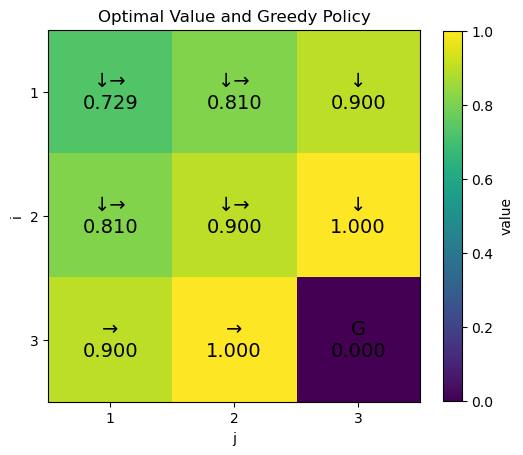

In [8]:
# 収束した V* と貪欲方策を可視化する
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(V_star, vmin=0, vmax=V_star.max())

ax.set_xticks(range(grid_size))
ax.set_yticks(range(grid_size))
ax.set_xticklabels(range(1, grid_size + 1))
ax.set_yticklabels(range(1, grid_size + 1))
ax.set_xlabel("j")
ax.set_ylabel("i")
ax.set_title("Optimal Value and Greedy Policy")

for i in range(grid_size):
    for j in range(grid_size):
        state = (i + 1, j + 1)
        if state == goal:
            text = "G\n0.000"
        else:
            text = f"{policy[state]}\n{V_star[i, j]:.3f}"
        ax.text(j, i, text, ha="center", va="center", fontsize=14)

fig.colorbar(im, ax=ax, shrink=0.8, label="value")
plt.show()

### 4. 理論値 $V^*(s)=\gamma^{d-1}$ と比較する

このグリッドワールドでは，ゴールに入るときだけ報酬 $1$ が得られる．  
そのため，ゴールまでの最短距離を $d$ とすると，最適価値は

$$
V^*(s)=\gamma^{d-1}
$$

になる．ただし，ゴールでは $V(G)=0$ とする．

In [9]:
def shortest_distance_to_goal(state):
    """グリッド上でゴールまでの最短距離を計算する関数"""
    return abs(goal[0] - state[0]) + abs(goal[1] - state[1])


def theoretical_value(state):
    """最短距離 d を使った理論値を返す関数"""
    d = shortest_distance_to_goal(state)

    if d == 0:
        return 0.0
    else:
        return gamma ** (d - 1)


rows = []
for s in states:
    d = shortest_distance_to_goal(s)
    v_value_iteration = get_value(V_star, s)
    v_theory = theoretical_value(s)

    rows.append({
        "state": s,
        "shortest distance d": d,
        "V* by value iteration": v_value_iteration,
        "theoretical V*": v_theory,
        "absolute error": abs(v_value_iteration - v_theory),
    })

comparison_df = pd.DataFrame(rows)
comparison_df["V* by value iteration"] = comparison_df["V* by value iteration"].round(6)
comparison_df["theoretical V*"] = comparison_df["theoretical V*"].round(6)
comparison_df["absolute error"] = comparison_df["absolute error"].round(12)

display(comparison_df)

print("最大誤差:", comparison_df["absolute error"].max())

,state,shortest distance d,V* by value iteration,theoretical V*,absolute error
0,"(1, 1)",4,0.729,0.729,0.0
1,"(1, 2)",3,0.810,0.810,0.0
2,"(1, 3)",2,0.900,0.900,0.0
3,"(2, 1)",3,0.810,0.810,0.0
4,"(2, 2)",2,0.900,0.900,0.0
5,"(2, 3)",1,1.000,1.000,0.0
6,"(3, 1)",2,0.900,0.900,0.0
7,"(3, 2)",1,1.000,1.000,0.0
8,"(3, 3)",0,0.000,0.000,0.0


最大誤差: 0.0


In [10]:
# 理論値をグリッド形式でも確認する
theory_grid = np.zeros((grid_size, grid_size))

for s in states:
    i, j = state_to_index(s)
    theory_grid[i, j] = theoretical_value(s)

print("価値反復で得た V*:")
display(value_to_dataframe(V_star))

print("理論値:")
display(value_to_dataframe(theory_grid))

print("差:")
display(value_to_dataframe(np.abs(V_star - theory_grid)))

価値反復で得た V*:


,j=1,j=2,j=3
i=1,0.729,0.81,0.9
i=2,0.810,0.90,1.0
i=3,0.900,1.00,0.0


理論値:


,j=1,j=2,j=3
i=1,0.729,0.81,0.9
i=2,0.810,0.90,1.0
i=3,0.900,1.00,0.0


差:


,j=1,j=2,j=3
i=1,0.0,0.0,0.0
i=2,0.0,0.0,0.0
i=3,0.0,0.0,0.0


# 考察

価値反復を行うと，まずゴールに隣接する状態の価値が $1$ になり，その後，ゴールから離れた状態へ価値が逆向きに伝播していく様子が確認できた．  
これは，報酬がゴールに入るときだけ得られるため，ゴールに近い状態ほど早い反復で価値が大きくなるからである．

収束後の貪欲方策では，各状態からゴールまでの最短経路に沿う方向が選ばれている．同じ長さの最短経路が複数ある状態では，複数の矢印を表示した．

また，価値反復で得られた $V^*$ は，ゴールまでの最短距離 $d$ を用いた理論値

$$
V^*(s)=\gamma^{d-1}
$$

と一致した．したがって，今回のグリッドワールドにおいて，価値反復によって最適価値関数と貪欲方策を正しく求めることができたと考えられる．

# AI使用について

ChatGPT を使用して，授業スライドの演習2の条件整理，価値反復の実装方針，貪欲方策と理論値比較の確認について補助を受けた．コードの構成やプロットの作成では，AI の出力を確認しながら必要に応じて修正した．